
# 🧩 Projekt: Řešení bludiště (DFS, BFS, A*) – Jupyter Notebook

Obsahuje:
- generátory bludišť
- algoritmy **DFS**, **BFS**, **A\*** s více heuristikami


!pip install matplotlib numpy pandas

In [17]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from tabulate import tabulate
import random, time, math, heapq
from collections import deque


## 🔧 Algorithms (DFS, BFS, A*)

In [ ]:

MOVES = [(-1, 0), (1, 0), (0, -1), (0, 1)] # Up, Down, Left, Right

def reconstruct_path(parent, start, goal):
    if goal not in parent:
        return []
    path = []
    node = goal
    while node is not None:
        path.append(node)
        node = parent.get(node)
    path.reverse()
    return path if path and path[0] == start else []

def bfs(maze, start, goal, is_free):
    t0 = time.time()
    q = deque([start])
    parent = {start: None}
    visited = {start}
    while q:
        r, c = q.popleft()
        if (r, c) == goal:
            break
        for dr, dc in MOVES:
            nr, nc = r + dr, c + dc
            if is_free(maze, nr, nc) and (nr, nc) not in visited:
                visited.add((nr, nc))
                parent[(nr, nc)] = (r, c)
                q.append((nr, nc))
    path = reconstruct_path(parent, start, goal)
    return {"name": "BFS", "path": path, "visited": visited, "runtime": time.time() - t0}

def dfs(maze, start, goal, is_free):
    t0 = time.time()
    stack = [start]
    parent = {start: None}
    visited = {start}
    while stack:
        r, c = stack.pop()
        if (r, c) == goal:
            break
        for dr, dc in MOVES:
            nr, nc = r + dr, c + dc
            if is_free(maze, nr, nc) and (nr, nc) not in visited:
                visited.add((nr, nc))
                parent[(nr, nc)] = (r, c)
                stack.append((nr, nc))
    path = reconstruct_path(parent, start, goal)
    return {"name": "DFS", "path": path, "visited": visited, "runtime": time.time() - t0}

def astar(maze, start, goal, is_free, heuristic="manhattan"):
    def manhattan(a, b): return abs(a[0] - b[0]) + abs(a[1] - b[1])
    def euclidean(a, b): return math.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)
    def diagonal(a, b): return max(abs(a[0] - b[0]), abs(a[1] - b[1]))

    if heuristic == "euclidean": h = euclidean
    elif heuristic == "diagonal": h = diagonal
    else: h = manhattan

    t0 = time.time()
    open_set = [(0, start)]
    parent = {start: None}
    g_score = {start: 0}
    visited = set()
    while open_set:
        _, current = heapq.heappop(open_set)
        if current in visited:
            continue
        visited.add(current)
        if current == goal:
            break
        r, c = current
        for dr, dc in MOVES:
            nr, nc = r + dr, c + dc
            nb = (nr, nc)
            if not is_free(maze, nr, nc):
                continue
            tentative_g = g_score[current] + 1
            if tentative_g < g_score.get(nb, math.inf):
                parent[nb] = current
                g_score[nb] = tentative_g
                f = tentative_g + h(nb, goal)
                heapq.heappush(open_set, (f, nb))
    path = reconstruct_path(parent, start, goal)
    return {"name": f"A* ({heuristic})", "path": path, "visited": visited, "runtime": time.time() - t0}


## 🧱 Generator

In [19]:

def gen_maze(rows, cols, density=0.3, seed=None):
    if seed is not None:
        random.seed(seed); np.random.seed(seed)
    maze = np.random.choice([0, 1], size=(rows, cols), p=[1 - density, density])
    maze[0, 0] = 0; maze[-1, -1] = 0
    return maze

def is_free(maze, r, c):
    return 0 <= r < maze.shape[0] and 0 <= c < maze.shape[1] and maze[r, c] == 0


## 🎨 Visualization

In [20]:

def draw_solution(maze, start, goal, result):
    plt.figure(figsize=(6, 6))
    colors = ["black", "#00FF00"]
    plt.imshow(maze, cmap=plt.matplotlib.colors.ListedColormap(colors))
    if result["visited"]:
        ys = [r for (r, c) in result["visited"]]
        xs = [c for (r, c) in result["visited"]]
        plt.scatter(xs, ys, c="#FFFFFF", s=6, alpha=0.5)
    if result["path"]:
        ys = [r for (r, c) in result["path"]]
        xs = [c for (r, c) in result["path"]]
        plt.plot(xs, ys, c="#FFFFFF", linewidth=2.5)
    plt.scatter([start[1]], [start[0]], c="#FFFFFF", marker="s", s=80)
    plt.scatter([goal[1]], [goal[0]], c="#FFFFFF", marker="X", s=80)
    plt.title(result["name"], fontsize=14, fontweight="bold", color="#00FF00")
    plt.axis("off")
    plt.show()

def show_results_grid(maze, start, goal, results, figsize=(16,6), spacing=0.06):
    fig, axes = plt.subplots(1, len(results), figsize=figsize, facecolor="black")
    if len(results) == 1:
        axes = [axes]
    for ax, res in zip(axes, results):
        colors = ["black", "#00FF00"]
        ax.imshow(maze, cmap=plt.matplotlib.colors.ListedColormap(colors))
        ax.set_facecolor("black")
        if res["visited"]:
            ys = [r for (r, c) in res["visited"]]; xs = [c for (r, c) in res["visited"]]
            ax.scatter(xs, ys, c="#FFFFFF", s=6, alpha=0.5)
        if res["path"]:
            ys = [r for (r, c) in res["path"]]; xs = [c for (r, c) in res["path"]]
            ax.plot(xs, ys, c="#FFFFFF", linewidth=2.5)
        ax.scatter([start[1]], [start[0]], c="#FFFFFF", marker="s", s=80)
        ax.scatter([goal[1]], [goal[0]], c="#FFFFFF", marker="X", s=80)
        ax.set_title(res["name"], fontsize=14, fontweight="bold", color="#00FF00")
        ax.axis("off")
    legend_elements = [
        Patch(facecolor="black", edgecolor="black", label="Free space"),
        Patch(facecolor="#00FF00", edgecolor="#00FF00", label="Wall"),
        Line2D([0], [0], color="#FFFFFF", lw=2, label="Found path"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#FFFFFF", markersize=6, label="Visited"),
        Line2D([0], [0], marker="s", color="w", markerfacecolor="#FFFFFF", markersize=10, label="Start"),
        Line2D([0], [0], marker="X", color="w", markerfacecolor="#FFFFFF", markersize=10, label="Goal"),
    ]
    fig.legend(handles=legend_elements, loc="lower center", ncol=6, frameon=False, fontsize=10, labelcolor="white", bbox_to_anchor=(0.5, -0.02))
    plt.subplots_adjust(left=0.02, right=0.98, top=0.9, bottom=0.15, wspace=spacing)
    plt.show()


## ⚙️ Parameters

In [21]:

rows, cols = 30, 30
start, goal = (0, 0), (rows-1, cols-1)

generator_type = "random"     # "random"
heuristic = "manhattan"      # "manhattan" / "euclidean" / "diagonal"
density = 0.30               #
seed = 34                    # for reproducibility
max_attempts = 50            # ensure path exists


## 🏗 Generate maze (with guaranteed path)

In [22]:

attempts = 0
valid = False
cur_seed = seed
while not valid and attempts < max_attempts:
    if generator_type == "random":
        maze_map = gen_maze(rows, cols, density=density, seed=cur_seed)
        maze_map[start] = 0
        maze_map[goal] = 0
        if bfs(maze_map, start, goal, is_free)["path"]:
            valid = True
        else:
            attempts += 1
            cur_seed += 1

if not valid:
    print("⚠️ Could not generate a valid maze. Try different parameters (density/seed/size).")
else:
    print(f"✅ Maze OK | generator={generator_type}, seed={cur_seed}, size={rows}x{cols}")


✅ Maze OK | generator=random, seed=34, size=30x30


## ▶️ Run algorithms + visualize

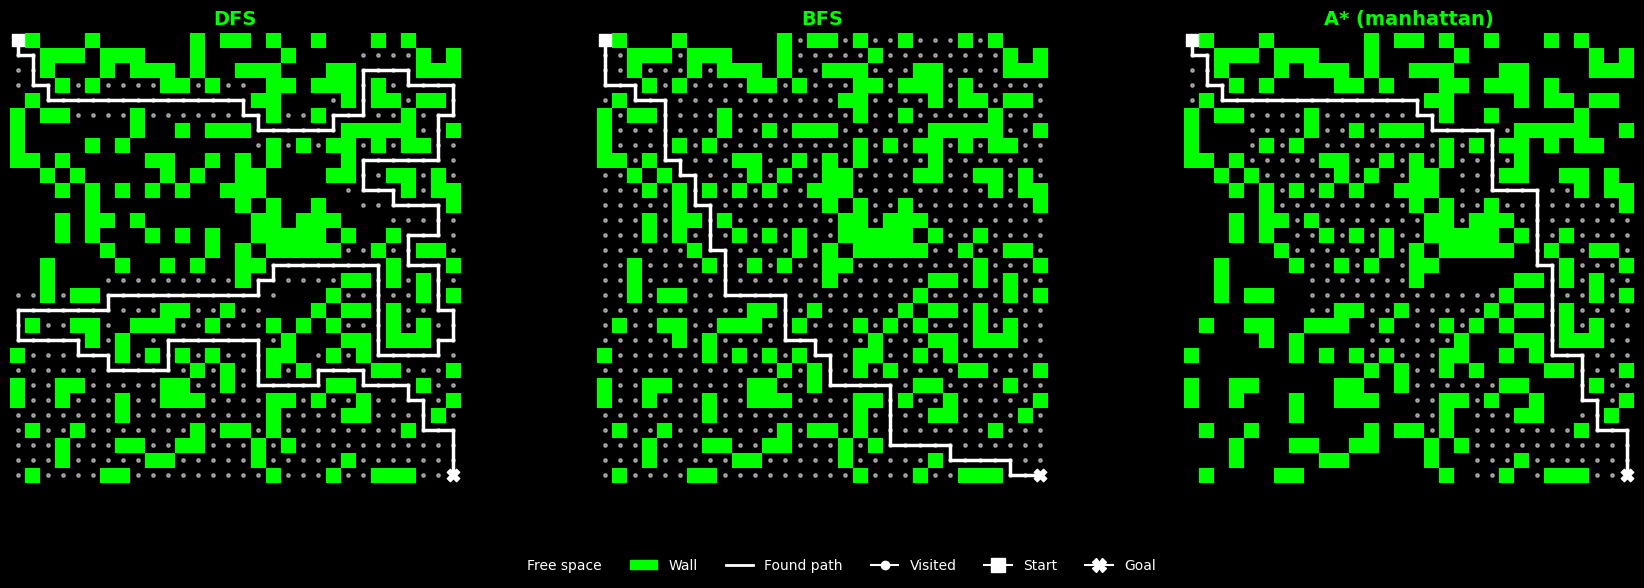

+----------------+-------------+----------------+----------+
|   Algorithm    | Path Length | Explored Nodes | Time (s) |
+----------------+-------------+----------------+----------+
|      DFS       |     158     |      425       | 0.000444 |
|      BFS       |     58      |      614       | 0.000668 |
| A* (manhattan) |     58      |      294       | 0.000498 |
+----------------+-------------+----------------+----------+


,Algorithm,Path Length,Explored Nodes,Time (s)
0,DFS,158,425,0.000444
1,BFS,58,614,0.000668
2,A* (manhattan),58,294,0.000498


In [23]:

results = [
    dfs(maze_map, start, goal, is_free),
    bfs(maze_map, start, goal, is_free),
    astar(maze_map, start, goal, is_free, heuristic),
]

show_results_grid(maze_map, start, goal, results, figsize=(18,6))

df = pd.DataFrame(
    [[r["name"], max(0, len(r["path"]) - 1), len(r["visited"]), round(r["runtime"], 6)] for r in results],
    columns=["Algorithm", "Path Length", "Explored Nodes", "Time (s)"]
)
print(tabulate(df, headers="keys", tablefmt="pretty", showindex=False))
df


## 🧪 (Optional) Benchmark – averaged over multiple random mazes

In [ ]:

def benchmark_algorithms(heuristic="manhattan", runs=10, size=(30,30), density=0.3):
    rows, cols = size
    all_rows = []
    for s in range(runs):
        m = gen_maze(rows, cols, density=density, seed=s)
        for algo in [dfs, bfs, lambda M,S,G,F: astar(M,S,G,F,heuristic)]:
            res = algo(m, (0,0), (rows-1, cols-1), is_free)
            if res["path"]:
                all_rows.append([res["name"], len(res["path"])-1, len(res["visited"]), res["runtime"]])
    if not all_rows:
        print("No valid benchmarks.")
        return None
    bdf = pd.DataFrame(all_rows, columns=["Algorithm", "Path Length", "Explored Nodes", "Time (s)"])
    avg = bdf.groupby("Algorithm").mean().reset_index()
    avg["Path Length"] = avg["Path Length"].astype(int)
    avg["Explored Nodes"] = avg["Explored Nodes"].astype(int)
    avg["Time (s)"] = avg["Time (s)"].round(5)
    print(tabulate(avg, headers="keys", tablefmt="pretty", showindex=False))
    return bdf, avg

# bdf, avg = benchmark_algorithms(heuristic="euclidean", runs=10, size=(30,30), density=0.3)